In [1]:
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Force GPU usage
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    try:
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found")

2026-01-13 12:58:48.758780: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/rithik/coding/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Num GPUs Available: 1
GPU memory growth enabled


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from pathlib import Path

In [3]:
data_dir = Path('/home/rithik/coding/deep_learning/data/PetImages')
cats_dir = data_dir / 'Cat'
dogs_dir = data_dir / 'Dog'
print(f"Cats directory exists: {cats_dir.exists()}")
print(f"Dogs directory exists: {dogs_dir.exists()}")

Cats directory exists: True
Dogs directory exists: True


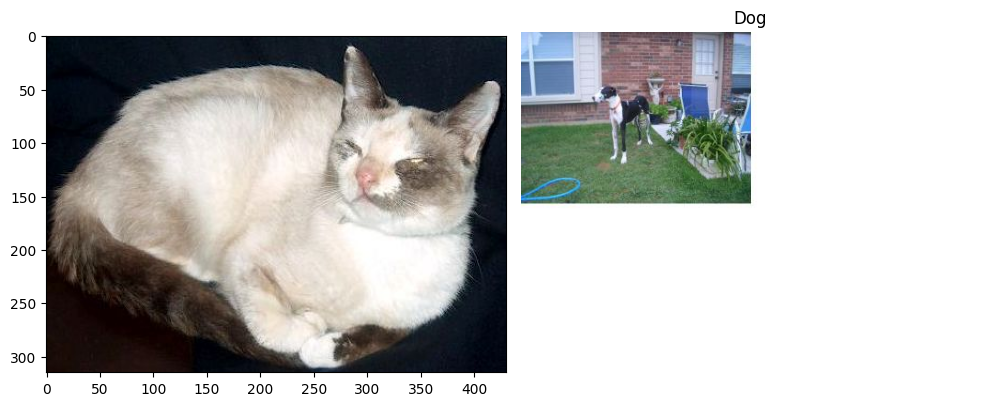

In [4]:
cats_img = list(cats_dir.glob('*'))
dogs_img = list(dogs_dir.glob('*'))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
img_1 = plt.imread(cats_img[500])
img_2 = plt.imread(dogs_img[500])
axes[0].imshow(img_1)
axes[1].imshow(img_2)
axes[1].set_title('Dog')
axes[1].axis('off')
plt.tight_layout()

In [5]:
import cv2
#normalization
cat_sam = []
dog_sam = []
var = 0
img_size = 128
for p in cats_img:
    if var == 1000:
        break
    var += 1
 
    try:
        img = plt.imread(p)
        if len(img.shape) < 3 or img.shape[2] != 3:
            continue
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype('float32')/255.0
        cat_sam.append(img)
    except Exception as e:
        print(f"Error loading {p}: {e}")
        continue

var = 0
for p in dogs_img:
    if var == 1000:
        break
    var += 1

    try:
        img = plt.imread(p)
        if len(img.shape) < 3 or img.shape[2] != 3:
            continue
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype('float32')/255.0
        dog_sam.append(img)
    except Exception as e:
        print(f"Error loading {p}: {e}")
        continue

In [6]:
len(cat_sam)
len(dog_sam)

997

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [8]:

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(layers.GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



/home/rithik/coding/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1768287550.238548    7744 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,777 (108.50 KB)

 Trainable params: 27,777 (108.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from sklearn.model_selection import train_test_split
X = np.vstack([np.array(cat_sam), np.array(dog_sam)])
y = np.hstack([np.zeros(len(cat_sam)), np.ones(len(dog_sam))])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} images")
print(f"Testing set: {len(X_test)} images")


history = model.fit(
    X_train, y_train,
    epochs=10,  
    batch_size=16,  
    validation_split=0.2,  
    verbose=1,
    steps_per_epoch=len(X_train)//16
)


Training set: 1595 images
Testing set: 399 images
Epoch 1/10


2026-01-13 12:59:15.790218: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b975c005dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-13 12:59:15.790256: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-01-13 12:59:15.947144: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-13 12:59:16.927641: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-13 12:59:17.807166: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call

13/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4650 - loss: 0.6939

I0000 00:00:1768287560.867933    7836 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


77/99 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5013 - loss: 0.6938

2026-01-13 12:59:22.694895: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-13 12:59:22.753485: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,32,64,64]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

80/99 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5018 - loss: 0.6937

/home/rithik/coding/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-13 12:59:26.377979: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":

99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.5165 - loss: 0.6935 - val_accuracy: 0.4765 - val_loss: 0.6935
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5361 - loss: 0.6913 - val_accuracy: 0.4608 - val_loss: 0.7041
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5674 - loss: 0.6852 - val_accuracy: 0.5862 - val_loss: 0.6662
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5721 - loss: 0.6792 - val_accuracy: 0.6364 - val_loss: 0.6558
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5956 - loss: 0.6672 - val_accuracy: 0.5956 - val_loss: 0.6311
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6183 - loss: 0.6409 - val_accuracy: 0.5674 - val_loss: 0.6449
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6270 - loss: 0.6330 - val_accuracy: 0.6364 - val_loss: 0.6142
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6105 - loss: 0.6348 - val_accuracy: 0.5674 - val_loss: 0

In [10]:
dog_sam[910].shape

(128, 128, 3)

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

2026-01-13 12:59:49.872779: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-13 12:59:50.187449: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,64,64]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

Test Loss: 0.6190
Test Accuracy: 0.6541
Test Accuracy: 65.41%


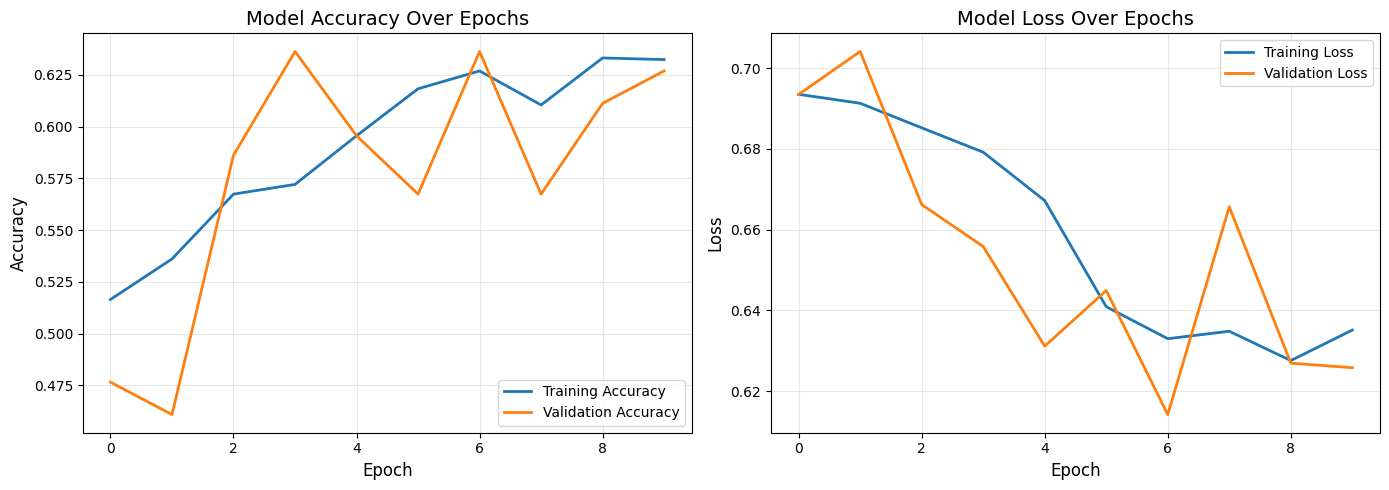

✓ Training visualization complete!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Over Epochs', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training visualization complete!")

In [13]:
y_test

array([0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0.,
       1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0.,
       1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1.,
       1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.,
       1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 1., 1., 1.